# Textual Analysis — Newspaper Headlines (2024 US Presidential Election)

Applies text mining techniques to newspaper article titles collected from Democratic- and Republican-leaning outlets (Jul 5 – Nov 4, 2024).

**Pipeline:**
1. Load & inspect data
2. Text preprocessing
3. Word clouds (raw + TF-IDF weighted)
4. TF-IDF: most distinctive words per leaning
5. Word co-occurrence network
6. Term frequency over time

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud
import networkx as nx

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv("./Data/1_Bronze/Newspaper/data.csv", parse_dates=["date"])
print(f"Total articles: {len(df)}")
print(df.groupby(["source", "leaning"]).size().to_string())
df.head()

Total articles: 7684
source          leaning   
Breitbart       Republican     653
Daily Caller    Republican     378
Fox News        Republican     958
NBC News        Democratic     435
NY Post         Republican     644
New York Times  Democratic     823
The Guardian    Democratic    3793


,source,leaning,date,title,url
0,The Guardian,Democratic,2024-07-05,Ukraine war briefing: Ukrainian army confirms ...,https://www.theguardian.com/world/article/2024...
1,The Guardian,Democratic,2024-07-05,"Labour bounceback, Tory collapse: five key tak...",https://www.theguardian.com/politics/article/2...
2,The Guardian,Democratic,2024-07-05,French PM urges calm after assaults in run-up ...,https://www.theguardian.com/world/article/2024...
3,The Guardian,Democratic,2024-07-05,‘Goodwill on all sides’: transfer of UK power ...,https://www.theguardian.com/politics/article/2...
4,The Guardian,Democratic,2024-07-05,Labour convinced voters it was the safest choi...,https://www.theguardian.com/politics/article/2...


## 1. Text Preprocessing

In [4]:
# Standard English stopwords + election/news noise words
stop_words = set(stopwords.words('english'))
custom_stops = {
    'says', 'say', 'said', 'new', 'one', 'two', 'us', 'year', 'years',
    'time', 'would', 'could', 'also', 'like', 'get', 'got', 'will',
    'may', 'back', 'way', 'first', 'last', 'week', 'day', 'make',
    'show', 'know', 'take', 'come', 'go', 'see', 'look', 'need',
    'trump', 'harris', 'kamala', 'donald' # too dominant — removed from clouds, kept for TF-IDF
}
stop_words = stop_words.union(custom_stops)

def preprocess(text_series):
    """Lowercase, remove punctuation/numbers/extra whitespace."""
    return (
        text_series
        .fillna('')
        .str.lower()
        .str.replace(r'[^\w\s]', ' ', regex=True)
        .str.replace(r'\d+', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

df['title_clean'] = preprocess(df['title'])
print("Sample preprocessed titles:")
df[['title', 'title_clean']].head(5)

Sample preprocessed titles:


,title,title_clean
0,Ukraine war briefing: Ukrainian army confirms ...,ukraine war briefing ukrainian army confirms r...
1,"Labour bounceback, Tory collapse: five key tak...",labour bounceback tory collapse five key takea...
2,French PM urges calm after assaults in run-up ...,french pm urges calm after assaults in run up ...
3,‘Goodwill on all sides’: transfer of UK power ...,goodwill on all sides transfer of uk power the...
4,Labour convinced voters it was the safest choi...,labour convinced voters it was the safest choi...


## 2. Word Clouds

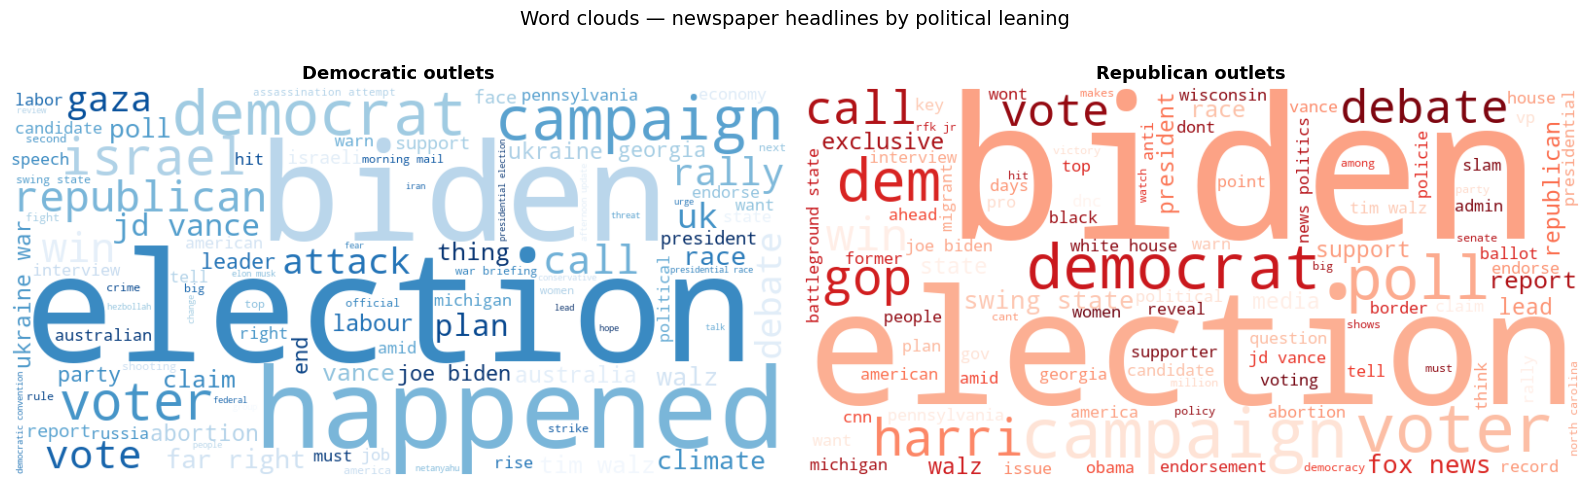

In [5]:
def make_wordcloud(text_series, title, colormap, ax):
    text = ' '.join(text_series)
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        stopwords=stop_words,
        max_words=100,
        colormap=colormap,
        relative_scaling=0.5,
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
make_wordcloud(df[df['leaning']=='Democratic']['title_clean'], 'Democratic outlets', 'Blues',  axes[0])
make_wordcloud(df[df['leaning']=='Republican']['title_clean'], 'Republican outlets', 'Reds',   axes[1])
plt.suptitle('Word clouds — newspaper headlines by political leaning', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../Data/Newspapers/data/wordcloud_leaning.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. TF-IDF: Most Distinctive Words per Leaning

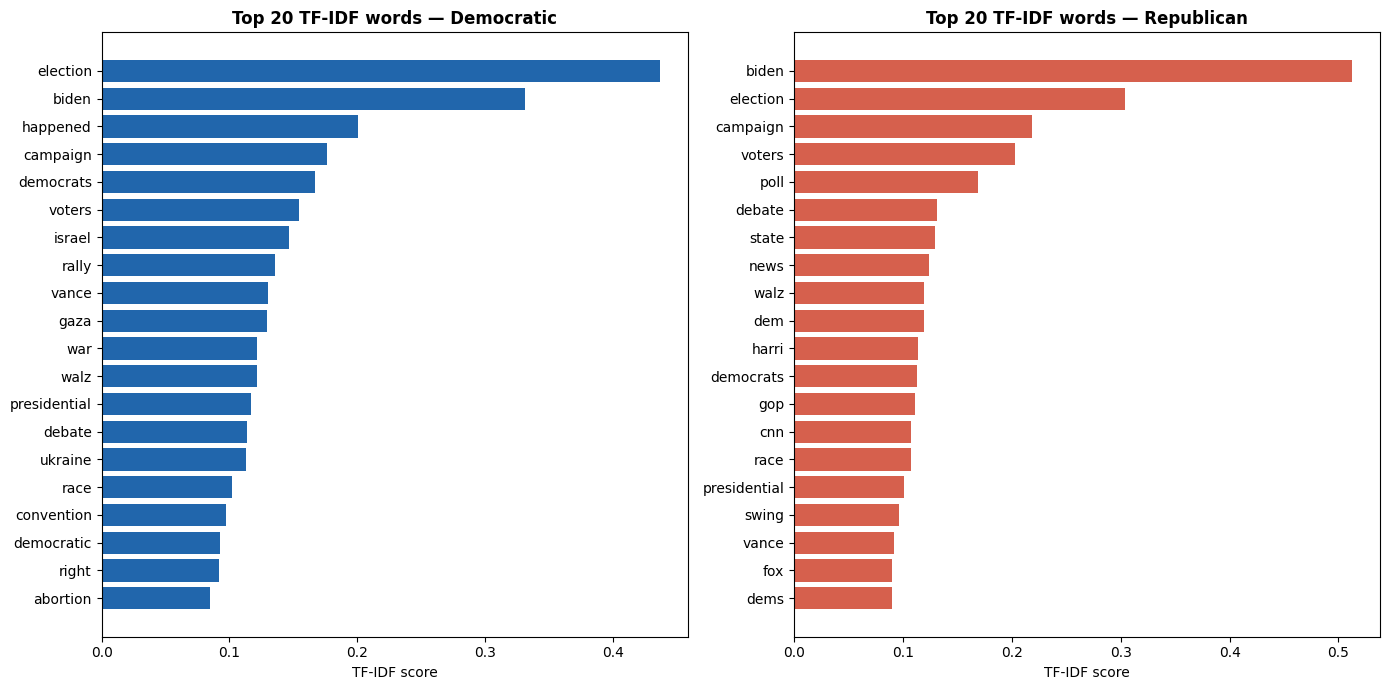

In [6]:
# One document per leaning (all titles concatenated)
groups = df.groupby('leaning')['title_clean'].apply(' '.join)

tfidf = TfidfVectorizer(
    token_pattern=r'\b\w{3,}\b',
    stop_words=list(stop_words),
    min_df=1,
    max_features=5000,
)
X      = tfidf.fit_transform(groups)
words  = np.array(tfidf.get_feature_names_out())
labels = groups.index.tolist()  # ['Democratic', 'Republican']

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
colors = {'Democratic': '#2166ac', 'Republican': '#d6604d'}

for i, leaning in enumerate(labels):
    scores  = X[i].toarray().flatten()
    top_idx = scores.argsort()[::-1][:20]
    axes[i].barh(words[top_idx][::-1], scores[top_idx][::-1], color=colors[leaning])
    axes[i].set_title(f'Top 20 TF-IDF words — {leaning}', fontweight='bold')
    axes[i].set_xlabel('TF-IDF score')

plt.tight_layout()
plt.savefig('../Data/Newspapers/data/tfidf_top_words.png', dpi=150)
plt.show()

## 4. Word Co-occurrence Network

Network: 15 nodes, 100 edges
Communities: 1, Modularity: 0.000


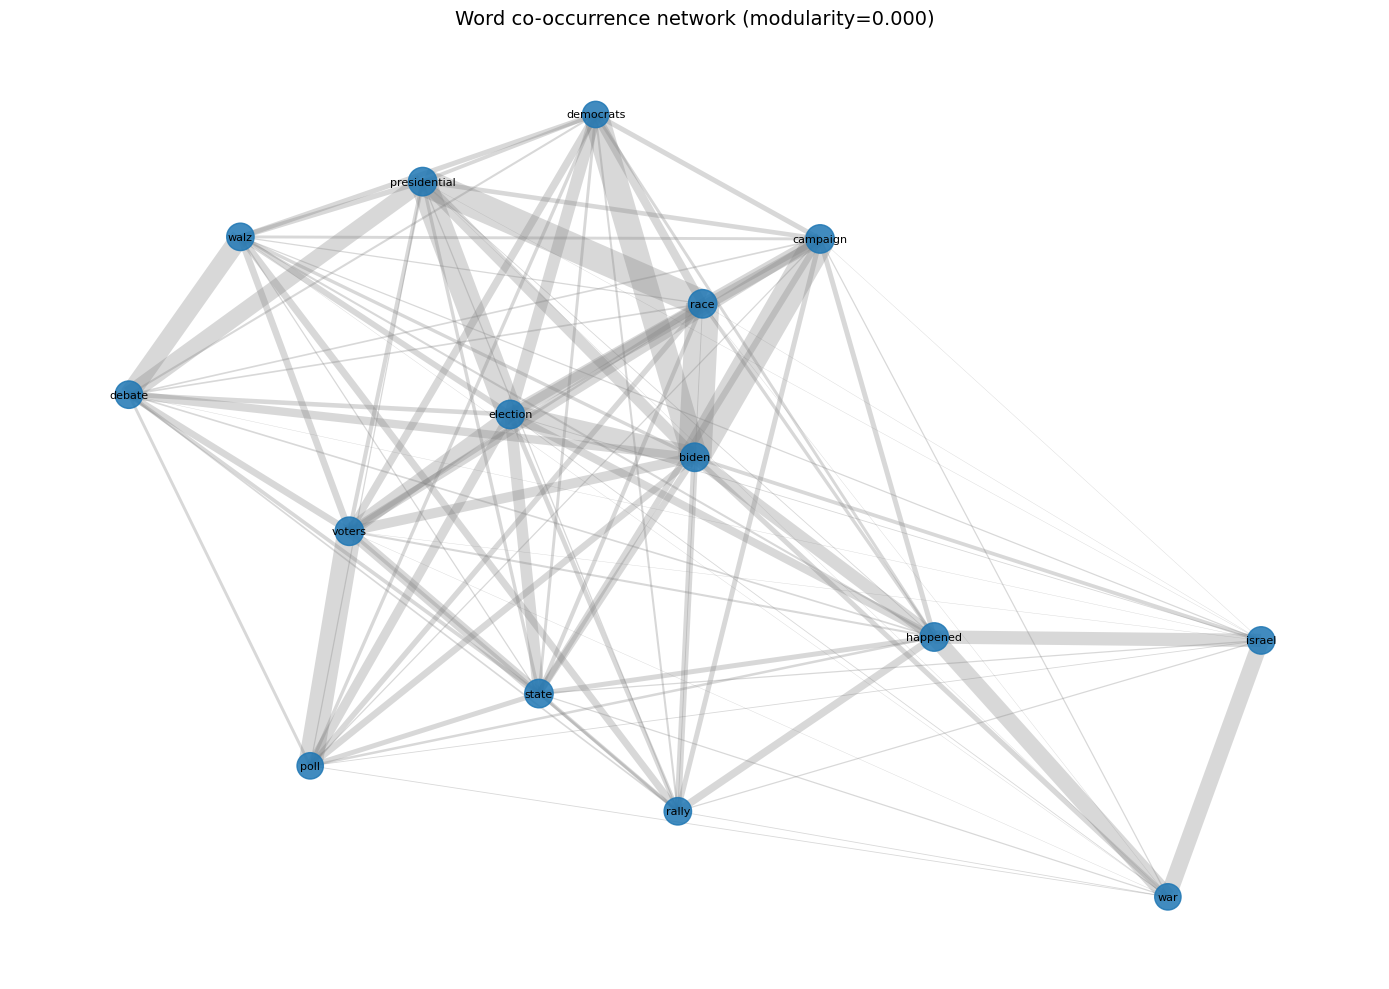

In [7]:
def build_cooccurrence_network(text_series, max_features=300, min_df=5, top_pct=95):
    """
    Nodes = words, edges = co-occurrence in same title, weighted by frequency.
    A = DTM^T × DTM  (as in lecture)
    """
    cv = CountVectorizer(
        token_pattern=r'\b\w{3,}\b',
        binary=True,
        stop_words=list(stop_words),
        max_features=max_features,
        min_df=min_df,
    )
    dtm   = cv.fit_transform(text_series)
    words = np.array(cv.get_feature_names_out())

    cooc = (dtm.T @ dtm).toarray()
    np.fill_diagonal(cooc, 0)

    # Keep only highly connected words (top percentile)
    degree    = cooc.sum(axis=1)
    threshold = np.percentile(degree, top_pct)
    mask      = degree >= threshold
    cooc_f    = cooc[np.ix_(mask, mask)]
    words_f   = words[mask]

    G = nx.from_numpy_array(cooc_f)
    G = nx.relabel_nodes(G, {i: words_f[i] for i in range(len(words_f))})
    return G

G   = build_cooccurrence_network(df['title_clean'])
mod = nx.community.modularity(G, list(nx.community.greedy_modularity_communities(G)))
communities = list(nx.community.greedy_modularity_communities(G))
print(f"Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Communities: {len(communities)}, Modularity: {mod:.3f}")

# Node colours per community
palette    = plt.cm.tab10.colors
node_color = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_color[node] = palette[i % len(palette)]

fig, ax = plt.subplots(figsize=(14, 10))
pos     = nx.spring_layout(G, k=1.5, iterations=50, seed=42)
weights = [G[u][v].get('weight', 1) for u, v in G.edges()]
degrees = dict(G.degree())

nx.draw_networkx_nodes(G, pos, ax=ax,
    node_size=[degrees[n] * 30 for n in G.nodes()],
    node_color=[node_color[n] for n in G.nodes()],
    alpha=0.85)
nx.draw_networkx_edges(G, pos, ax=ax,
    width=[w * 0.3 for w in weights],
    alpha=0.3, edge_color='grey')
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)

ax.set_title(f'Word co-occurrence network (modularity={mod:.3f})', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('../Data/Newspapers/data/cooccurrence_network.png', dpi=150)
plt.show()

## 5. Term Frequency Over Time

Track how often key election topics appear weekly in Democratic vs Republican outlets.

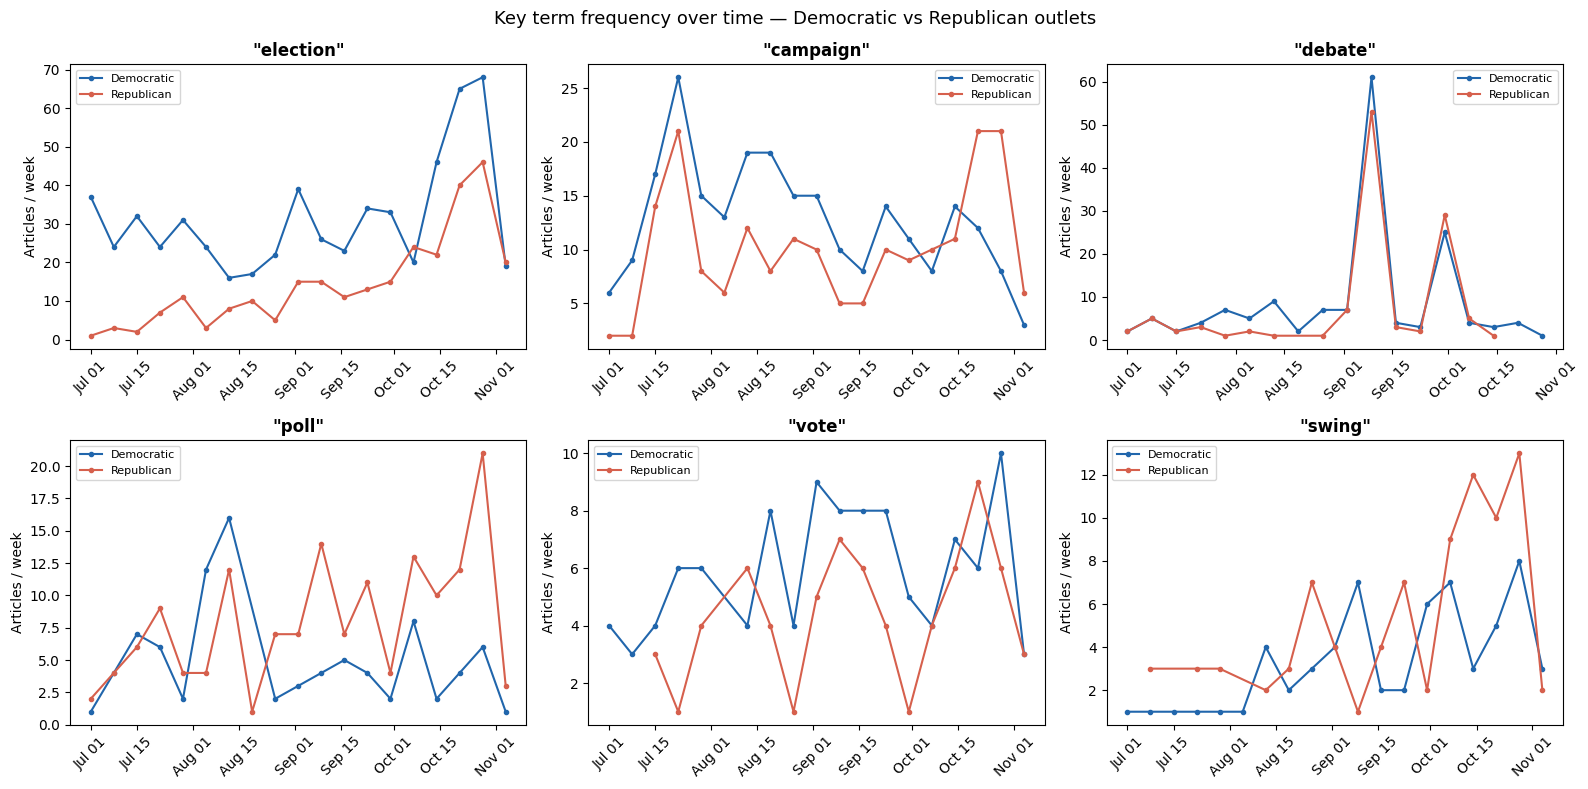

In [8]:
TRACK_TERMS = ['debate', 'poll', 'abortion', 'immigration', 'economy',
               'campaign', 'vote', 'election', 'swing', 'battleground']

df['week'] = df['date'].dt.to_period('W').dt.start_time

results = []
for term in TRACK_TERMS:
    mask   = df['title_clean'].str.contains(r'\b' + term + r'\b', regex=True, na=False)
    weekly = df[mask].groupby(['week', 'leaning']).size().reset_index(name='count')
    weekly['term'] = term
    results.append(weekly)

term_df   = pd.concat(results, ignore_index=True)
top_terms = term_df.groupby('term')['count'].sum().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
colors = {'Democratic': '#2166ac', 'Republican': '#d6604d'}

for ax, term in zip(axes.flat, top_terms):
    subset = term_df[term_df['term'] == term]
    for leaning, color in colors.items():
        data = subset[subset['leaning'] == leaning]
        ax.plot(data['week'], data['count'], label=leaning, color=color, marker='o', ms=3)
    ax.set_title(f'"{term}"', fontweight='bold')
    ax.set_ylabel('Articles / week')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

plt.suptitle('Key term frequency over time — Democratic vs Republican outlets', fontsize=13)
plt.tight_layout()
plt.savefig('../Data/Newspapers/data/term_frequency_over_time.png', dpi=150)
plt.show()